# Pythonによる確率分布の実装

ここではSciPyライブラリを用いて、確率分布の各種処理（分布形状の可視化、最尤推定etc.）を実装する方法を解説します。

## 基本的な手順

SciPyで確率分布を実装するためには、以下の条件を指定する必要があります。

- 確率分布の種類の選択
- 関数の選択
- 入出力の指定

例えば正規分布の確率密度関数を出力したい場合、以下のように条件を指定します。

- 確率分布の種類：正規分布（`scipy.stats.norm`クラスを選択）
- 関数の選択：確率密度関数（`pdf`関数を選択）
- 入出力の指定：確率密度関数の横軸xを配列で渡す

これは以下のようなコードで実装できます。

In [1]:
# コード4.1 正規分布の確率密度関数の出力例
import numpy as np
from scipy import stats

x = np.linspace(-3.5, 3.5, 200) # 入力データx
MU = 0 # 平均パラメータ
SIGMA = 1 # 標準偏差パラメータ
px = stats.norm.pdf(x, loc=MU, scale=SIGMA) # 確率密度関数を出力

出力された関数を可視化してみます

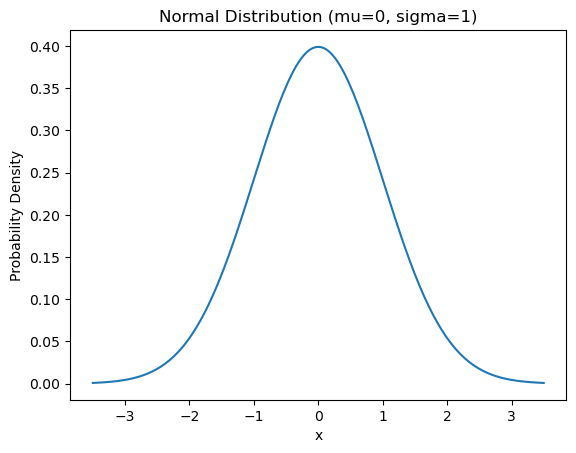

In [2]:
import matplotlib.pyplot as plt

# 確率密度関数をプロットする関数
def plot_pdf(x, px, title, params):
    plt.plot(x, px)
    plt.title(f'{title} ({", ".join([f"{k}={v}" for k, v in params.items()])})')
    plt.xlabel('x')
    plt.ylabel('Probability Density')
    plt.show()

plot_pdf(x, px, 'Normal Distribution', params={'mu': MU, 'sigma': SIGMA})

### 確率分布の種類の選択

確率分布の選択には、`scipy.stats`パッケージ内の各確率分布を表すクラスを指定します。

|確率分布の種類|SciPyのクラス|パラメータ1|パラメータ2|
|---|---|---|---|
|正規分布|`norm`|`loc`（平均パラメータ$\mu$）|`scale`（標準偏差パラメータ$\sigma$）|
|対数正規分布|`lognorm`|`s`（パラメータ$\sigma$）|`scale`（パラメータ$\mu$の指数$\exp(\mu)$）|
|カイ二乗分布|`chi2`|`df`（自由度パラメータ$k$）|-|
|スチューデントのt分布|`t`|`df`（自由度パラメータ$k$）|-|
|二項分布|`binom`|`n`（試行数パラメータ$n$）|`p`（成功確率パラメータ$\mu$）|
|ポアソン分布|`poisson`|`mu`（期待発生回数パラメータ$\mu$）|-|
|指数分布|`expon`|`scale`（平均間隔パラメータ$\lambda$の逆数$\frac{1}{\lambda}$）|-|
|ガンマ分布|`gamma`|`a`（形状母数パラメータ$k$）|`scale`（尺度母数パラメータ$\theta$）|
|一様分布（連続型）|`uniform`|`loc`（最小値パラメータ$\min$）|`scale`（最大値$\max$-最小値$\min$）|
|一様分布（離散型）|`randint`|`low`（最小値パラメータ$\min$）|`high`（最大値パラメータ$\max+1$）|

#### 正規分布

正規分布を実装するには、[scipy.stats.norm](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html)クラスを使用します。平均パラメータ$\mu$は引数`loc`で、標準偏差パラメータは引数`scale`で指定します。
コード4.2 正規分布の確率密度関数

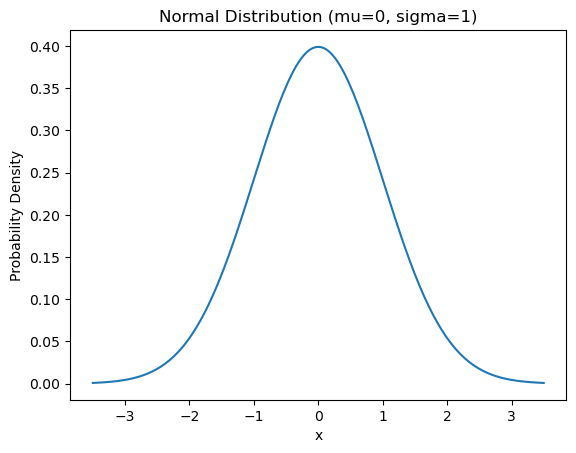

In [3]:
MU = 0 # 平均パラメータμ
SIGMA = 1 # 標準偏差パラメータσ
# 確率密度関数を出力
px = stats.norm.pdf(x, loc=MU, scale=SIGMA)

# プロット
plot_pdf(x, px, 'Normal Distribution', params={'mu': MU, 'sigma': SIGMA})

#### 対数正規分布

対数正規分布を実装するには、[scipy.stats.lognorm](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.lognorm.html)クラスを使用します。パラメータ$\sigma$は引数`s`で指定できますが、パラメータ$\mu$は引数`scale`に$\exp{\mu}$として渡す必要があることにご注意ください。またこれらの一般的なパラメータ以外にも、x軸方向へのオフセット値を`loc`引数に渡すことができます。

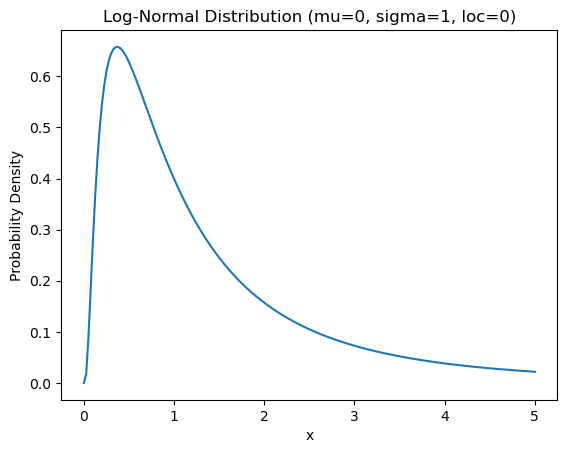

In [4]:
# コード4.3 対数正規分布の確率密度関数
MU = 0 # パラメータμ
SIGMA = 1 # パラメータσ
LOC = 0 # x軸方向のオフセット
# 描画するx軸用データの生成（0〜5の範囲の実数）
x = np.linspace(0, 5, 200)
# 確率密度関数を出力
px = stats.lognorm.pdf(x, s=SIGMA, scale=np.exp(MU), loc=LOC)

# プロット
plot_pdf(x, px, 'Log-Normal Distribution', params={'mu': MU, 'sigma': SIGMA, 'loc': LOC})

#### カイ二乗分布

カイ二乗分布を実装するには、[scipy.stats.chi2](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2.html)クラスを使用します。⾃由度パラメータ$k$は引数`df`で指定できます。またパラメータ$k$以外にも、x軸方向へのオフセット値を`loc`引数に、x軸方向への拡大倍率を`scale`引数に渡すことができます。



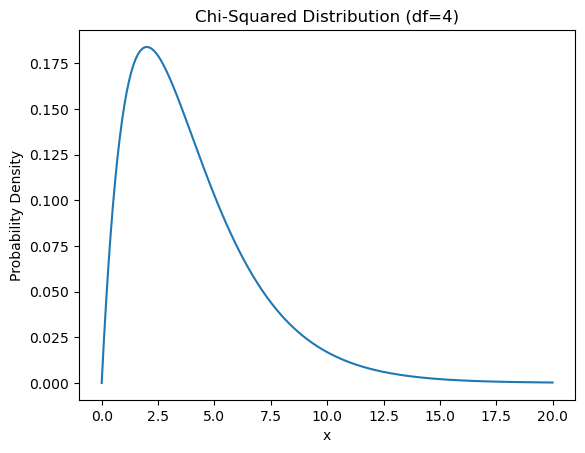

In [5]:
# コード4.4 カイ二乗分布の確率密度関数
# 描画するx軸用データの生成（0〜20の範囲の実数）
x = np.linspace(0, 20, 200)

DF = 4 # ⾃由度パラメータk
# 確率密度関数を出力
px = stats.chi2.pdf(x, df=DF)

# プロット
plot_pdf(x, px, 'Chi-Squared Distribution', params={'df': DF})

#### スチューデントのt分布

スチューデントのt 分布を実装するには、[scipy.stats.t](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html)クラスを使用します。⾃由度パラメータ$k$は引数`df`で指定できます。またパラメータ$k$以外にも、x軸方向へのオフセット値を`loc`引数に、x軸方向への拡大倍率を`scale`引数に渡すことができます。

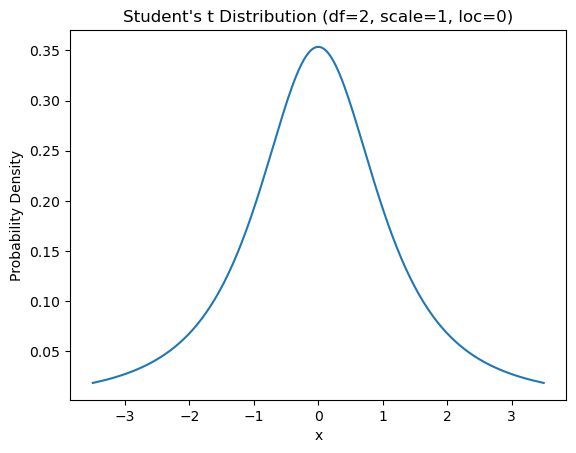

In [6]:
# コード4.5 スチューデントのt分布の確率密度関数
# 描画するx軸用データの生成（-3.5〜3.5の範囲の実数）
x = np.linspace(-3.5, 3.5, 200)

DF = 2 # ⾃由度パラメータk
SCALE = 1 # x軸方向の拡⼤倍率
LOC = 0 # x軸方向のオフセット
# 確率密度関数を出力
px = stats.t.pdf(x, df=DF, scale=SCALE, loc=LOC)

# プロット
plot_pdf(x, px, 'Student\'s t Distribution', params={'df': DF, 'scale': SCALE, 'loc': LOC})

#### 二項分布

二項分布を実装するには、[scipy.stats.binom](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binom.html)クラスを使用します。試行数パラメータ$n$は引数`n`で、成功確率パラメータ（本文中では「発生率パラメータ」と呼称）$\mu$は引数`p`で指定します。

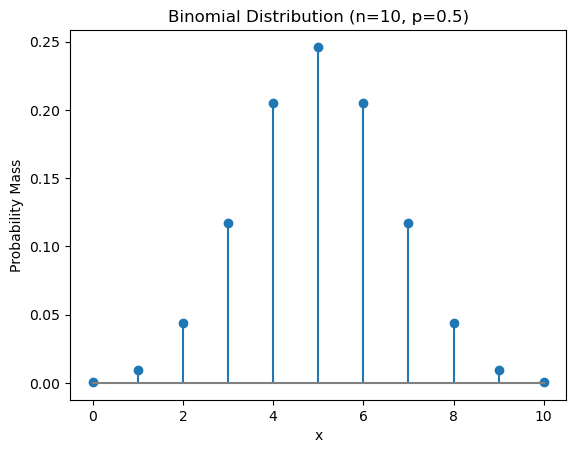

In [7]:
# コード4.6 二項分布の確率質量関数
# 確率質量関数をプロットする関数
def plot_pmf(x, px, title, params):
    plt.stem(x, px, basefmt="grey")
    plt.title(f'{title} ({", ".join([f"{k}={v}" for k, v in params.items()])})')
    plt.xlabel('x')
    plt.ylabel('Probability Mass')
    plt.show()

N = 10 # 試行数パラメータn
MU = 0.5 # 発生率パラメータμ
# 描画するx軸用データの生成（0〜Nの範囲内の整数）
x = np.arange(N+1)
# 確率質量関数を出力
px = stats.binom.pmf(x, n=N, p=MU)

# プロット
plot_pmf(x, px, 'Binomial Distribution', params={'n': N, 'p': MU})

#### ポアソン分布

ポアソン分布を実装するには、[scipy.stats.poisson](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.poisson.html)クラスを使用します。期待発生回数パラメータ$\mu$は引数`mu`で指定します。

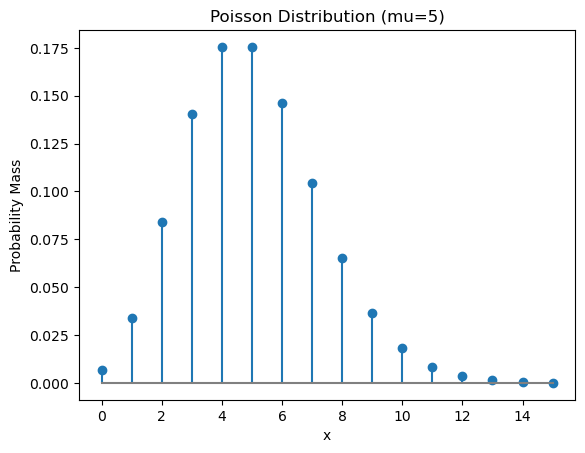

In [8]:
# コード4.7 ポアソン分布の確率密度関数
MU = 5 # 期待発生回数パラメータμ
# 描画するx軸用データの生成（0〜3MUの範囲内の整数）
x = np.arange(3*MU + 1)
# 確率質量関数を出力
px = stats.poisson.pmf(x, mu=MU)

# プロット
plot_pmf(x, px, 'Poisson Distribution', params={'mu': MU})

#### 指数分布

指数分布を実装するには、[scipy.stats.expon](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.expon.html)クラスを使用します。平均間隔パラメータ$\lambda$ではなく、尺度母数$\theta=\frac{1}{\lambda}$を引数scale に渡す必要があることにご注意ください。

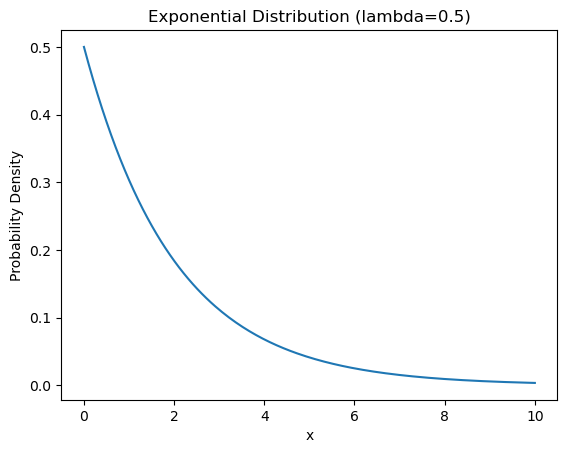

In [9]:
# コード4.8 指数分布の確率密度関数
# 描画するx軸用データの生成（0〜10の範囲の実数）
x = np.linspace(0, 10, 200)

LAMBDA = 0.5 # 平均間隔パラメータλ
# 確率密度関数を出力
px = stats.expon.pdf(x, scale=1/LAMBDA)

# プロット
plot_pdf(x, px, 'Exponential Distribution', params={'lambda': LAMBDA})

#### ガンマ分布

ガンマ分布を実装するには、[scipy.stats.gamma](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.gamma.html)クラスを使用します。形状母数パラメータ$k$は引数`a`で、尺度母数パラメータ$\theta$は引数`scale`で指定します。

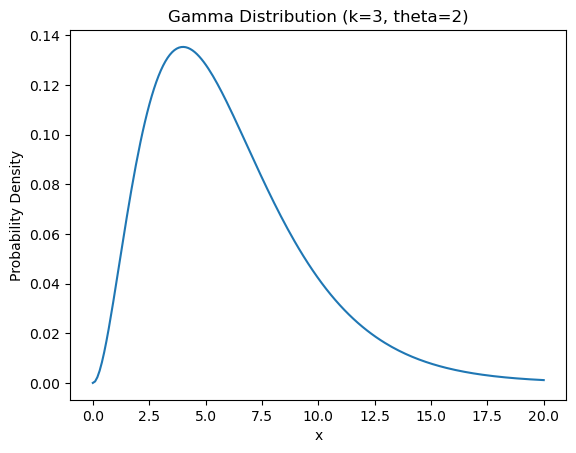

In [10]:
# コード4.9 ガンマ分布の確率密度関数
# 描画するx軸用データの生成（0〜20の範囲の実数）
x = np.linspace(0, 20, 200)

K = 3 # 形状母数パラメータk
THETA = 2 # 尺度母数パラメータθ
# 確率密度関数を出力
px = stats.gamma.pdf(x, a=K, scale=THETA)

# プロット
plot_pdf(x, px, 'Gamma Distribution', params={'k': K, 'theta': THETA})

#### 一様分布（連続型）

連続型の一様分布を実装するには、[scipy.stats.uniform](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.uniform.html)クラスを使用します。最⼩値パラメータ$min$は引数`loc`で、最⼤値パラメータ$max$は引数`scale`に$max − min$を渡すことで指定します。

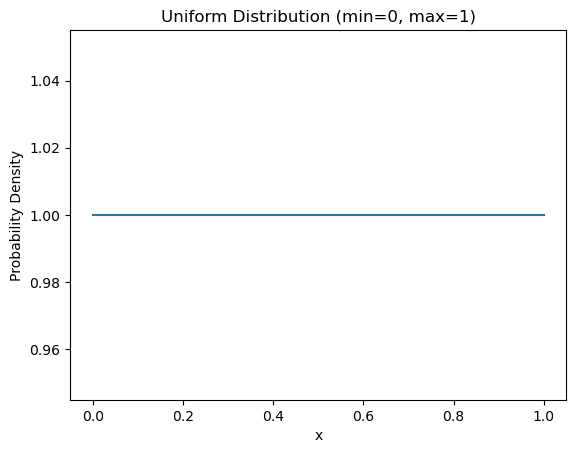

In [11]:
# コード4.10 一様分布（連続型）の確率密度関数
MIN = 0 # 最⼩値パラメータmin
MAX = 1 # 最⼤値パラメータmax
# 描画するx軸用データの生成（MIN〜MAXの範囲の実数）
x = np.linspace(MIN, MAX, 200)
# 確率密度関数を出力
px = stats.uniform.pdf(x, loc=MIN, scale=MAX-MIN)

# プロット
plot_pdf(x, px, 'Uniform Distribution', params={'min': MIN, 'max': MAX})

#### 一様分布（離散型）
整数型の離散型一様分布を実装するには、[scipy.stats.randint](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.randint.html)クラスを使用します。最⼩値パラメータ$min$は引数`low`で、最⼤値パラメータ$max$は引数`high`に$max + 1$を渡すことで指定します。

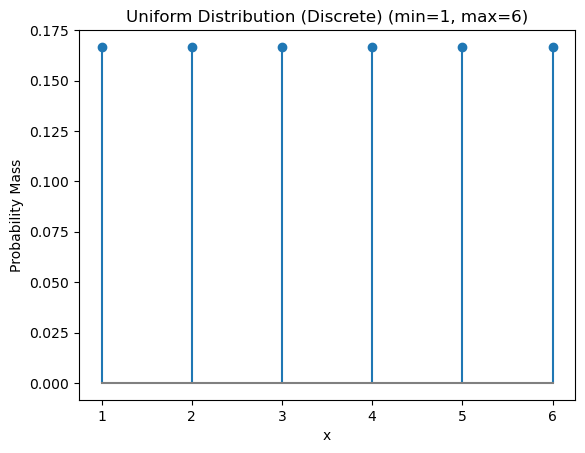

In [12]:
#コード4.11 一様分布（離散型）の確率密度関数
MIN = 1 # 最⼩値パラメータmin
MAX = 6 # 最⼤値パラメータmax
# 描画するx軸用データの生成（MIN〜MAXの範囲内の整数）
x = np.arange(MIN, MAX + 1)
# 確率質量関数を出力
px = stats.randint.pmf(x, low=MIN, high=MAX+1)

# プロット
plot_pmf(x, px, 'Uniform Distribution (Discrete)', params={'min': MIN, 'max': MAX})

### 関数の選択

異常検知では、確率密度関数、確率質量関数、累積分布関数などの確率分布の関数を、用途に応じて使い分ける必要があります。例えば、ヒストグラムと比較してデータへのフィッティングを定性的に確認する用途では確率密度関数・確率質量関数を用い、ターゲットとする誤報率に基づき異常度のしきい値を決定する用途では累積分布関数を用います。

関数の種類を指定するには、前の手順で選択した確率分布の種類を表すクラスに続けて、関数の種類を表すメソッドを選択します。例えば正規分布の確率密度関数を利用したい場合、正
規分布を表す`scipy.stats.norm`クラスに続けて確率密度関数を表す`pdf`メソッドを記述し、`scipy.stats.norm.pdf(x, loc=0, scale=1)`のように指定します。以下の表に、使用頻度の高い関数を一覧で示します。

| 名称        | 概要                       | メソッド名    | 確率変数の形態              |
| --------- | ------------------------ | -------- | ------------ |
| 確率密度関数    | 確率変数のある値での確率密度           | `pdf`    | 連続型                  |
| 確率質量関数    | 確率変数がある値をとる確率            | `pmf`    | 離散型                  |
| 確率密度関数の対数 | 確率密度関数の対数                | `logpdf` | 連続型                  |
| 確率質量関数の対数 | 確率質量関数の対数                | `logpmf` | 離散型                  |
| 累積分布関数    | 確率変数がある値以下となる確率          | `cdf`    | 連続型・離散型              |
| 生存関数      | 確率変数がある値より大きい確率（1−`CDF`）   | `sf`     | 連続型・離散型              |
| パーセント点関数  | 累積分布関数の逆関数（パーセンタイル）      | `ppf`    | 連続型・離散型              |
| 逆生存関数     | 生存関数の逆関数                 | `isf`    | 連続型・離散型              |
| 最尤推定      | 最尤推定でパラメータを推定 | `fit`    | 連続型・離散型（※一部確率分布は対象外） |
| 乱数生成      | 確率分布に従う乱数（サンプル）の生成       | `rvs`    | 連続型・離散型              |

#### 確率密度関数

**確率密度関数**（probability density function）は連続型確率分布の確率密度を表す関数で、連続型において単に「確率分布」というとこの確率密度関数を指すことが一般的です。SciPyでは、確率密度関数は`pdf`メソッドで選択できます。例えば入力`x`に対する指数分布の確率密度関数を求めたい場合、以下のように記述します。

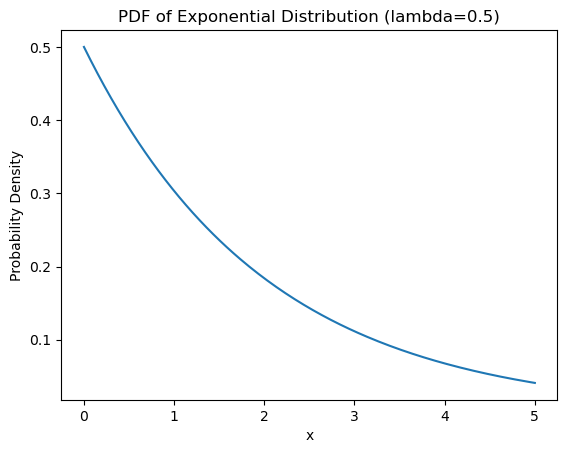

In [13]:
# コード4.12 確率密度関数の選択例
# 入力するx軸用データの生成（0〜5の範囲の実数）
x = np.linspace(0, 5, 200)

# 確率密度関数を取得
px = stats.expon.pdf(x, scale=2)

# プロット
plot_pdf(x, px, 'PDF of Exponential Distribution', params={'lambda': 1/2})

#### 確率質量関数

**確率質量関数**（probability mass function）は離散型確率分布において入力値をとる確率を表す関数で、離散型において単に「確率分布」というとこの確率質量関数を指すことが一般的です。SciPyでは、確率質量関数は`pdf`メソッドで選択できます。例えば入力`x`に対するポアソン分布の確率質量関数を求めたい場合、以下のように記述します。

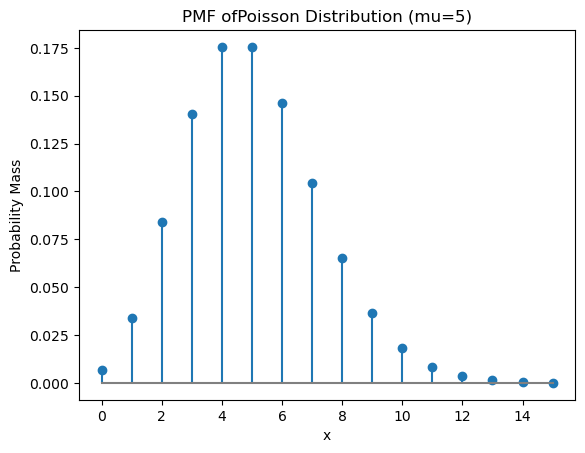

In [14]:
# コード4.13 確率質量関数の選択例
# 入力するx軸用データの生成（0〜15の範囲の整数）
x = np.arange(0, 16)

# 確率質量関数を取得
px = stats.poisson.pmf(x, mu=5)

# プロット
plot_pmf(x, px, 'PMF ofPoisson Distribution', params={'mu': 5})

#### 確率密度関数の対数・確率質量関数の対数

確率密度関数の対数（log of the probability density function）は確率密度関数の対数を取ったものです。この関数は、対数尤度を求める際などに便利です。SciPyでは、確率密度関数の対数は`logpdf`メソッドで選択できます。例えば入力`x`に対する正規分布の確率密度関数の対数を求めるには、以下のように記述します。

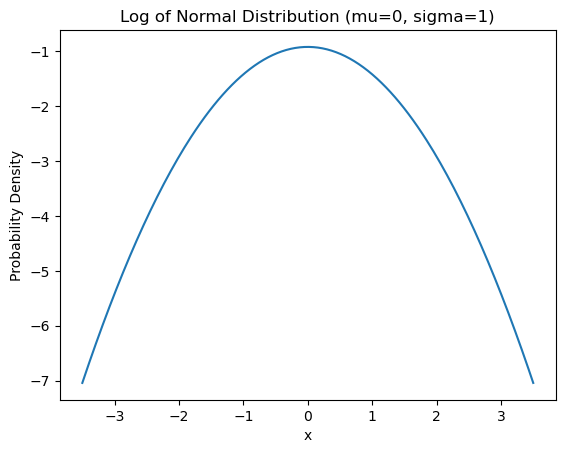

In [15]:
# コード4.14 確率密度関数の対数の選択例
# 入力するx軸用データの生成（-3.5〜3.5の範囲の実数）
x = np.linspace(-3.5, 3.5, 200)

# 確率密度関数の対数を取得
px = stats.norm.logpdf(x, loc=0, scale=1)

# プロット
plot_pdf(x, px, 'Log of Normal Distribution', params={'mu': 0, 'sigma': 1})

また、確率質量関数の対数をとったものを確率質量関数の対数（log of the probability mass function）と呼びます。SciPyでは、確率質量関数の対数は`logpmf`メソッドで選択できます。例えば入力`x`に対する二項分布の確率質量関数の対数を求めたい場合、以下のように記述します。

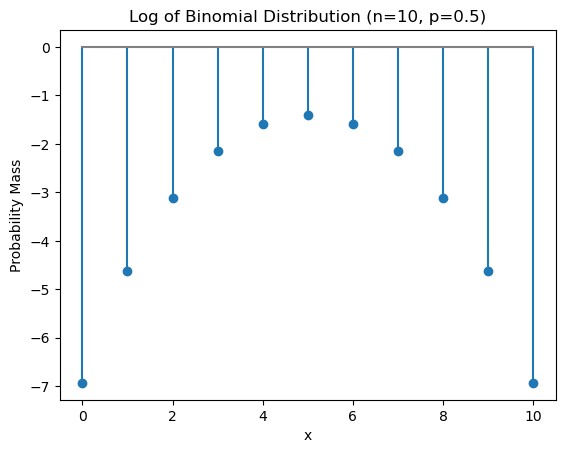

In [16]:
# コード4.15 確率質量関数の対数の選択例
# 入力するx軸用データの生成（0〜10の範囲の整数）
x = np.arange(0, 11)

# 確率質量関数の対数を取得
px = stats.binom.logpmf(x, n=10, p=0.5)

# プロット
plot_pmf(x, px, 'Log of Binomial Distribution', params={'n': 10, 'p': 0.5})

#### 累積分布関数

**累積分布関数**（cumulative distribution function）は、確率分布において指定した値以下をとる確率を表す関数です。SciPyで累積分布関数は、連続型、離散型いずれの確率分布であっても`cdf`メソッドで選択できます。例えば入力`x`に対するポアソン分布の累積分布関数を求めたい場合、以下のように記述します。

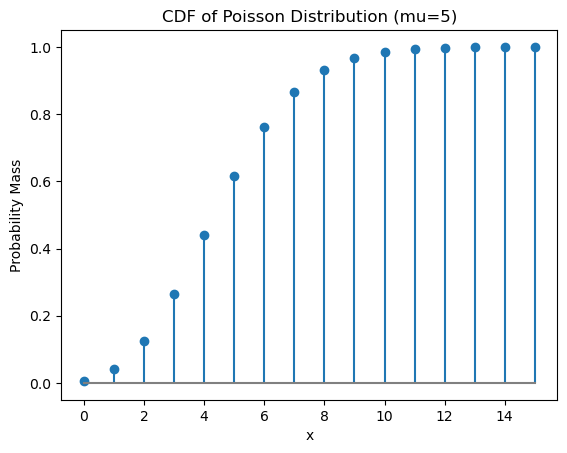

In [17]:
# コード4.16 累積分布関数の選択例
# 入力するx軸用データの生成（0〜15の範囲の整数）
x = np.arange(0, 16)

# 累積分布関数を取得
px = stats.poisson.cdf(x, mu=5)

# プロット
plot_pmf(x, px, 'CDF of Poisson Distribution', params={'mu': 5})

また累積分布関数とは逆に、確率分布において指定値よりも⼤きな値をとる確率を**生存関数**（survival function）と呼びます。生存関数は「1$−$累積分布関数」で表されます。SciPyでは、生存関数は`sf`メソッドで選択できます。例えば入力`x`に対する正規分布の生存関数を求めたい場合、以下のように記述します。

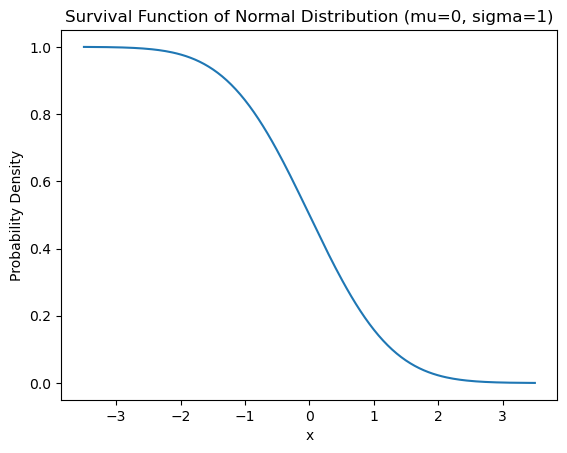

In [18]:
# コード4.17 生存関数の選択例
# 入力するx軸用データの生成（-3.5〜3.5の範囲の実数）
x = np.linspace(-3.5, 3.5, 200)

# 生存関数を取得
px = stats.norm.sf(x, loc=0, scale=1)

# プロット
plot_pdf(x, px, 'Survival Function of Normal Distribution', params={'mu': 0, 'sigma': 1})

#### パーセント点関数

**パーセント点**（percent point）とは、累積分布関数がある値となる確率変数の値を指します。パーセント点を入力として確率変数の値を返す関数を**パーセント点関数**（percent point function）と呼び、累積分布関数の逆関数を意味します。

例えば標準正規分布においては、確率変数の値が$2.0$のとき（一般の正規分布における$2\sigma$に相当）累積分布関数はおおよそ$0.977$（$97.7\%$）となります。よって標準正規分布の$97.7$パーセント点は、$2.0$となります。SciPy では、パーセント点関数は`ppf`メソッドで選択できます。例えば入力が$0.977$のときの標準正規分布のパーセント点関数（$= 97.7$パーセント点）を求めたい場合、以下のように記述します。

In [19]:
# コード4.18 パーセント点関数の選択例
stats.norm.ppf(0.977, loc=0, scale=1)

np.float64(1.9953933101678247)

また累積分布関数の代わりに生存関数（$=$1 − 累積分布関数）の逆関数をとったものを、**逆生存関数**（inverse survival function）と呼びます。SciPyでは、逆生存関数は`isf`メソッドで選択できます。例えば入力が$0.023$のときの標準正規分布の逆生存関数（パーセント点で表すと、$1−0.023 = 0.977$より$97.7$パーセント点に相当）を求めるには、以下のように記述します。

In [20]:
# コード4.19 逆生存関数の選択例
stats.norm.isf(0.023, loc=0, scale=1)

np.float64(1.9953933101678247)

一般的に教師なし学習による異常検知では、「1− 累積分布関数」すなわち生存関数がターゲットとする誤報率と等しくなるようにしきい値を調整します。よってターゲットとする誤報率が$1\%$であれば、モデルの確率分布（または異常度の確率分布）の逆生存関数の入力に`0.01`を渡すことで、しきい値を求めることができます。

#### 乱数生成

**乱数**（random number）とは、ある確率分布に従ってランダムに生成されたサンプルを指します。このようなサンプルを得ることを乱数生成と呼びます。SciPyでは、乱数生成は`rvs`メソッドにより実行できます。例えば標準正規分布に従うサンプルを1000個生成する場合、以下のように記述します。

In [21]:
# コード4.20 正規分布に従う乱数の生成例
stats.norm.rvs(loc=0, scale=1, size=1000)

array([ 6.90367938e-01, -1.84700735e-01, -1.22809521e+00, -4.53144730e-02,
        9.63179733e-01,  3.92029097e-01,  9.29690701e-01, -4.79103308e-01,
       -6.87565393e-01,  1.65793558e+00,  5.57972682e-01,  1.42458700e-01,
        1.31157755e+00,  1.26298644e+00,  1.27713499e+00, -1.47131867e+00,
       -6.61584332e-02, -1.74808766e+00, -5.95243846e-01,  1.90793959e+00,
        2.17760416e+00, -9.30766790e-01, -9.08766230e-01,  4.65626999e-01,
       -1.00353117e+00, -1.58883281e+00, -1.40965624e+00,  4.19726481e-01,
        9.66996251e-01, -1.06419813e+00, -3.47032533e-01, -7.92565528e-01,
       -1.88026695e-01, -1.13333167e+00,  8.44945575e-01,  6.54236447e-01,
       -1.60474750e+00,  1.54208151e+00,  3.94485096e-01,  1.53406017e+00,
        5.71851476e-02, -1.35034872e+00,  6.62571255e-01, -1.35290241e+00,
       -9.13813881e-01,  2.84147568e-01, -3.47272600e-01,  9.37078772e-01,
        7.73103221e-01, -3.27578471e-01,  9.74054213e-01, -7.29855239e-01,
       -9.55935458e-01,  

### 入出力の指定

SciPyで確率分布を生成するためには、関数の横軸を表す数値や配列（入力）と、確率密度関数などの生成した関数を格納するためのオブジェクト（出力先）を指定します。
入力データには、単一の数値、Python標準のリスト、NumPyのndarrayなどを指定できます。また生成した関数をオブジェクト`y`に格納したいときは、`y = stats.norm.pdf(x, loc=0, scale=1)`のように指定します。以下に、入力データの形式を変えて標準正規分布（平均0、分散1の正規分布）の累積分布関数を求める例を示します。

In [22]:
# コード4.21 SciPy の確率分布メソッドに入力可能なデータ形式の例
from scipy import stats
import numpy as np

# 単一の数値が入力（出力も単一）
x1 = 1.0
y1 = stats.norm.cdf(x1, loc=0, scale=1)
print(f"{y1}, type={type(y1)}")
# Python標準のリストが入力（対応する出力が配列で返される）
x2 = [-2.0, -1.0, 0.0, 1.0, 2.0]
y2 = stats.norm.cdf(x2, loc=0, scale=1)
print(f"{y2}, type={type(y2)}")
# numpy.ndarray（対応する出力が配列で返される）
x3 = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
y3 = stats.norm.cdf(x3, loc=0, scale=1)
print(f"{y3}, type={type(y3)}")

0.8413447460685429, type=<class 'numpy.float64'>
[0.02275013 0.15865525 0.5        0.84134475 0.97724987], type=<class 'numpy.ndarray'>
[0.02275013 0.15865525 0.5        0.84134475 0.97724987], type=<class 'numpy.ndarray'>


どの入力データの形式であっても出力はNumPy形式となっており、入力をnumpy.ndarray形式とすると、入出力で形式が変わらず扱いやすいことがわかります。また、ユースケースに応じて適切な入力データの形状を理解しておくと、可視化や検知において効率的なデータの持ち方を検討できるようになります。ここでは異常検知で頻繁に発生するユースケースと、適した入力データの形式を紹介します。

#### 例1：最尤推定

後ほど改めて解説しますが、異常検知におけるモデルの学習、すなわち正常データに確率分布を当てはめる操作には、最尤推定がよく用いられます。この最尤推定における入力データは、学習データ（正常データ）を表す配列です。例えば2章で作成したサンプルデータの`temp1`変数に対して正規分布の最尤推定を実施したい場合、以下のように正常データを抽出してndarray に変換したデータを、最尤推定の入力とするとよいでしょう（データに欠測値があると計算できないため、事前に欠測値を除去してください）。

In [23]:
# コード4.22 SciPy による確率分布パラメータの最尤推定
import pandas as pd

# CSVからデータ読み込み
df = pd.read_csv("./datasets/ch2_dataset_train.csv")
df_dropna = df.dropna(subset="temp1") # 欠測値削除
df_normal = df_dropna[df_dropna["label"] == "normal"] # 正常データのみを抽出
x = df_normal["temp1"].to_numpy() # "temp1"列を抽出してndarrayに変換
params = stats.norm.fit(x) # 最尤推定

params

(np.float64(400.21552883243925), np.float64(4.958226656997426))

#### 例2：確率分布の可視化

確率分布の形状、特に確率密度関数や確率質量関数の形状を可視化するには、確率密度・確率質量がある程度⼤きい変数の範囲において、均等に生成したデータを入力とするとよいでしょう。

例えば正規分布においては、平均$\mu$から離れるほど確率密度関数は⼩さくなり、$4\sigma$の範囲内に全体の$99.99\%$が収まります。よって$\mu \pm 4\sigma$をx軸の範囲としたグラフを作成すれば、確率分布の形状を把握するには十分と言えるでしょう。標準正規分布を例にとると、以下のように`np.linspace`関数で$\mu \pm 4\sigma$の範囲内に均等にデータを生成し、確率密度関数の入力`x`として渡します。

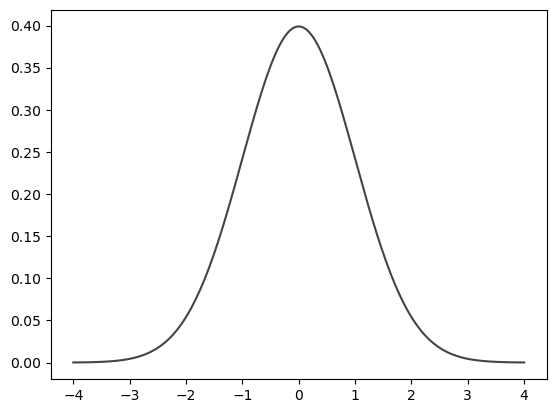

In [24]:
# コード4.23 SciPy による正規分布の確率密度関数の可視化例
MU = 0 # 平均パラメータμ
SIGMA = 1 # 標準偏差パラメータσ
# 描画するX軸用データの生成（μ±4σの範囲内で200等分）
x = np.linspace(MU - 4*SIGMA, MU + 4*SIGMA, 200)
# 確率密度関数を出力して可視化
y = stats.norm.pdf(x, loc=MU, scale=SIGMA)
plt.plot(x, y, color="#444444")

また離散型の確率分布、特に二項分布やポアソン分布のように整数が台となる確率分布においては、`np.arange`関数で整数の配列を生成するとよいでしょう。

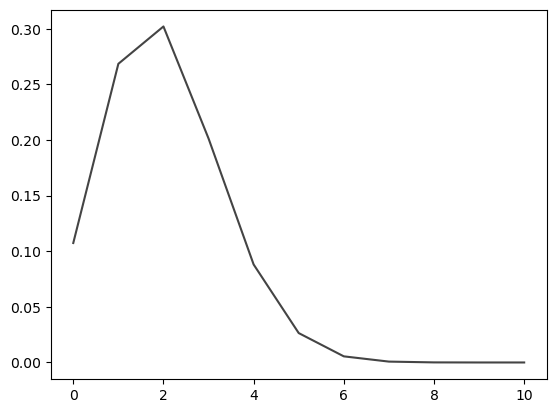

In [25]:
# コード4.24 SciPy による二項分布の確率質量関数の可視化例
N = 10 # 試行数パラメータn
P = 0.2 # 確率パラメータp
# 描画するx軸用データの生成（0〜Nの範囲内の整数）
x = np.arange(N+1)
# 確率質量関数を出力して可視化
y = stats.binom.pmf(x, n=N, p=P)
plt.plot(x, y, color="#444444")

## 最尤推定

教師なし学習による異常検知では、正常データに確率分布を当てはめることで、「正常のふるまい」をモデル化します。上で紹介した基本的な確率分布を用いて、データにそ
れらの分布を当てはめる操作は、確率分布のパラメータをデータにフィットするよう推定することを意味します。**最尤推定**（maximum likelihood estimation）は、このようなデータ
$\boldsymbol{X} = (x^{(1)}, x^{(2)},\cdots, x^{(N)})$に対して、当てはまりの良い確率分布のパラメータ$\boldsymbol{\theta}$を求める代表的な方法です。

PythonではSciPyライブラリを用いて多くの確率分布の最尤推定値を求めることができます。各確率分布における具体的な最尤推定の算出アルゴリズムは、[SciPyの公式ドキュメント](https://docs.scipy.org/doc/scipy/reference/stats.htmlを参照してください)。なお、一部の確率分布はSciPyによる最尤推定が実装されていないことにご注意ください（公式ドキュメントに`fit`メソッドが記載されているかどうかで判断できます）。

SciPyの最尤推定には、先ほどの「関数の選択」と同様に、確率分布の種類を表すクラスに続けてfit メソッドを記述します。例えば正規分布の場合、`params = scipy.stats.norm.fit(データ)`となります。以下で正規分布およびカイ二乗分布における最尤推定の実装例を紹介します。

### 例1：正規分布の最尤推定の実装

正規分布の平均パラメータ$\mu$と標準偏差パラメータ$\sigma$をScipyで最尤推定し、推定された正規分布を元のデータのヒストグラムと重ねてプロットする例を、以下に示します（なお、正規分布の最尤推定は標本平均と標本標準偏差を求めるだけなので、SciPyを使わずにNumPy等で計算することもできます）。

mu=3.9123055038183785, sigma=2.021912096573899


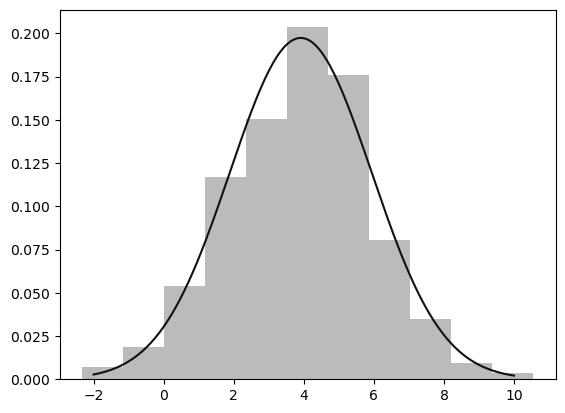

In [26]:
# コード4.25 正規分布の最尤推定の実装例
# サンプルとして平均4、標準偏差2の正規分布からデータを1000個生成
x = stats.norm.rvs(loc=4, scale=2, size=1000)
# 最尤推定を実行
params = stats.norm.fit(x)
loc = params[0] # 推定した平均パラメータ
scale = params[1] # 推定した標準偏差パラメータ
print(f"mu={loc}, sigma={scale}")
# データのヒストグラムと最尤推定した正規分布を重ねて表示
plt.hist(x=x, color="#bbbbbb", bins="sturges", density=True)
xline = np.linspace(-2, 10, 200)
estimated_dist = stats.norm.pdf(xline, loc=loc, scale=scale)
plt.plot(xline, estimated_dist, color="#111111")

推定したパラメータ（コード中の`params`）はtuple型の配列として得られます。得られるパラメータの種類は確率分布ごとに異なりますが、一般的には最後の要素に`scale`パラメータ
（正規分布では標準偏差）、最後から2番目の要素に`loc`パラメータ（正規分布では平均）が、それより前の要素に他のパラメータが格納されます。

### 例2：カイ二乗分布の最尤推定の実装

SciPyによるカイ二乗分布や対数正規分布の実装では、一般的な確率分布のパラメータには含まれない、`loc`（オフセット）や`scale`（スケール変換）といったパラメータについても考慮する必要があります。デフォルトではこれらのパラメータも最尤推定の対象となるため。このような一般的ではないパラメータを推定対象から外すには、パラメータの値を固定します。

例えばカイ二乗分布で`loc`と`scale`パラメータを固定し、パラメータ$k$（SciPyでは`df`）のみを最尤推定の対象としたい場合、以下の実装例に示すように`fit`メソッドに`floc`および`fscale`引数を指定します。

df=np.float64(4.050683593750007),loc=0,scale=1


(0.0, 21.1)

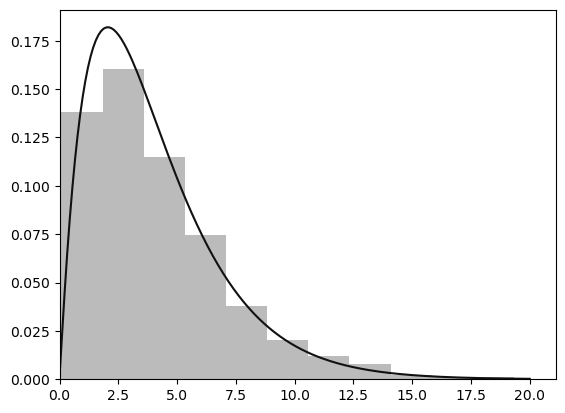

In [27]:
# コード4.26 カイ二乗分布の最尤推定の実装例
# サンプルとして⾃由度k=4のカイ二乗分布からデータを1000個生成
x = stats.chi2.rvs(df=4, size=1000)
# 最尤推定を実行（locとscaleを0と1に固定する）
params = stats.chi2.fit(x, floc=0, fscale=1)
df = params[0] # 推定したパラメータdf
loc = params[1] # 固定したパラメータloc
scale = params[2] # 固定したパラメータscale
print(f"{df=},{loc=},{scale=}")
# データのヒストグラムと最尤推定したカイ二乗分布を重ねて表示
plt.hist(x=x, color="#bbbbbb", bins="sturges", density=True)
xline = np.linspace(-2, 20, 200)
estimated_dist = stats.chi2.pdf(xline, loc=loc, scale=scale, df=df)
plt.plot(xline, estimated_dist, color="#111111")
plt.xlim(left=0)

推定した⾃由度$k$（Pythonの変数名では`df`）が最初に与えた値とほぼ一致しており、グラフを見てもヒストグラムと推定した分布形状がフィットしているため、うまく最尤推定できていることがわかります。